<a href="https://colab.research.google.com/github/Jiyoung169/Uber_Review_Analysis/blob/main/analysis_of_uber_user_reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Comprehensive Analysis of Uber Customer Sentiment and Service Quality Trends (2025)**
* BAN200OBB: Sentiment Analysis and Text Mining
* Group3: Veronica Hoo, Vincent Le, Ivan Keov, Jiyoung Choi and Harsimran Singh


### **Project_Group3: Project Workflow & Role Distribution**
* Data Integration & Cleaning: Veronica
* Text Preprocessing: Vincent and Ivan
* Exploratory Data Analysis (EDA): Jiyoung and Harsimran

In [ ]:
# Library Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import kagglehub
import os

import tensorflow as tf
import keras
import re
import nltk
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

!pip install google_play_scraper
from google_play_scraper import Sort, reviews
from datetime import datetime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.1 MB/s eta 0:00:00


**Webscraping: Veronica Hoo**

In [ ]:
#Scrape user reviews from Google Play Store
app_id = 'com.ubercab'
all_reviews = []
continuation_token = None
target_date = datetime(2025, 1, 1)

while True:
    result, continuation_token = reviews(
        app_id,
        lang='en',
        country='us',
        sort=Sort.NEWEST,
        count=10000,
        continuation_token=continuation_token
    )
    all_reviews.extend(result)


    last_date = result[-1]['at']
    print(last_date)

    if last_date < target_date:
        break

    if not continuation_token:
        break

2026-03-06 11:10:27
2026-02-12 16:15:36
2026-01-21 12:57:35
2025-12-29 12:24:51
2025-12-07 16:46:29
2025-11-18 09:19:22
2025-10-31 15:31:14
2025-10-06 09:07:16
2025-09-12 15:04:19
2025-08-17 08:52:47
2025-07-29 07:23:45
2025-07-10 11:12:57
2025-06-24 16:31:01
2025-06-03 15:47:58
2025-05-14 14:25:57
2025-04-26 07:38:08
2025-04-07 19:38:23
2025-03-19 11:06:42
2025-02-25 22:33:40
2025-02-03 16:11:58
2025-01-14 16:09:10
2024-12-24 12:39:47


In [ ]:
# Convert to pandas dataframe
df_uber_reviews = pd.DataFrame(all_reviews)

# Change review 'at' column to datetime format
df_uber_reviews['at'] = pd.to_datetime(df_uber_reviews['at'])

# Filter to show reviews from 2025 only
df_reviews_2025 = df_uber_reviews[
    (df_uber_reviews['at'] >= '2025-01-01') &
    (df_uber_reviews['at'] <= '2025-12-31')
].copy()

# Make sure that filtering was applied correctly
print(f"Limit of reviews we set: {len(df_uber_reviews)}")
print(f"Number of reviews from 2025: {len(df_reviews_2025)}")
df_reviews_2025.head

Limit of reviews we set: 220000
Number of reviews from 2025: 177181


<bound method NDFrame.head of                                     reviewId           userName  \
39352   6a6eeb34-cfce-4025-acfc-7a706abfe577     keith crumpton   
39353   74f095a6-837c-4d33-bda4-5e8dcc22c311      Nathan Phelan   
39354   0d80ae69-6fa9-436f-998b-64f4afd9a7c6  Shayne Pozzessere   
39355   72a88391-cae5-4f2a-9e89-01a69237e605        Christopher   
39356   eaadc7fe-4313-404c-8f39-3db80b4b56a8  Jannick Danielsen   
...                                      ...                ...   
216528  63628449-a632-40a2-ba32-f273d7b290a7      A Google user   
216529  5785a4e1-383b-47db-b9bf-416547e940a3      A Google user   
216530  2006bc91-8d2b-4b2c-b7e1-296e99ec6fb1      A Google user   
216531  e4a713ff-d9e0-43de-a7d6-29bc8be339a4      A Google user   
216532  81125e55-818c-4e11-acf9-00a8eb6f783e      A Google user   

                                                userImage  \
39352   https://play-lh.googleusercontent.com/a-/ALV-U...   
39353   https://play-lh.googleusercontent.com/a/ACg8oc...   
39354   https://play-lh.googleusercontent.com/a/ACg8oc...   
39355   https://play-lh.googleusercontent.com/a/ACg8oc...   
39356   https://play-lh.googleusercontent.com/a-/ALV-U...   
...                                                   ...   
216528  https://play-lh.googleusercontent.com/EGemoI2N...   
216529  https://play-lh.googleusercontent.com/EGemoI2N...   
216530  https://play-lh.googleusercontent.com/EGemoI2N...   
216531  https://play-lh.googleusercontent.com/EGemoI2N...   
216532  https://play-lh.googleusercontent.com/EGemoI2N...   

                                                  content  score  \
39352             great driver , knows the area and safe.      5   
39353                                The worst app of all      1   
39354   seriously!!! are the people behind this app ju...      1   
39355   Uber bringing the night life back to Winnipeg ...      5   
39356   Every time I use this app, there's no cars in ...      1   
...                                                   ...    ...   
216528                       The driver was very friendly      5   
216529  They charged me twice multiple times. Support ...      1   
216530                                          Very good      5   
216531                                            Amazing      5   
216532                                          Excellent      5   

        thumbsUpCount reviewCreatedVersion                  at replyContent  \
39352               0          4.609.10005 2025-12-30 23:50:16         None   
39353               0          4.609.10005 2025-12-30 23:46:19         None   
39354               2          4.609.10005 2025-12-30 23:34:18         None   
39355               0          4.609.10005 2025-12-30 23:32:53         None   
39356               0          4.609.10005 2025-12-30 23:32:38         None   
...               ...                  ...                 ...          ...   
216528              0          4.556.10007 2025-01-01 00:06:13         None   
216529              0          4.556.10007 2025-01-01 00:03:50         None   
216530              0          4.550.10001 2025-01-01 00:03:48         None   
216531              0          4.556.10007 2025-01-01 00:03:18         None   
216532              0                 None 2025-01-01 00:01:42         None   

       repliedAt   appVersion  
39352        NaT  4.609.10005  
39353        NaT  4.609.10005  
39354        NaT  4.609.10005  
39355        NaT  4.609.10005  
39356        NaT  4.609.10005  
...          ...          ...  
216528       NaT  4.556.10007  
216529       NaT  4.556.10007  
216530       NaT  4.550.10001  
216531       NaT  4.556.10007  
216532       NaT         None  

[177181 rows x 11 columns]>

In [ ]:
# Check that filtering (to 2025 data only) was completed successfully
df_reviews_2025.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
39352,6a6eeb34-cfce-4025-acfc-7a706abfe577,keith crumpton,https://play-lh.googleusercontent.com/a-/ALV-U...,"great driver , knows the area and safe.",5,0,4.609.10005,2025-12-30 23:50:16,None,NaT,4.609.10005
39353,74f095a6-837c-4d33-bda4-5e8dcc22c311,Nathan Phelan,https://play-lh.googleusercontent.com/a/ACg8oc...,The worst app of all,1,0,4.609.10005,2025-12-30 23:46:19,None,NaT,4.609.10005
39354,0d80ae69-6fa9-436f-998b-64f4afd9a7c6,Shayne Pozzessere,https://play-lh.googleusercontent.com/a/ACg8oc...,seriously!!! are the people behind this app ju...,1,2,4.609.10005,2025-12-30 23:34:18,None,NaT,4.609.10005
39355,72a88391-cae5-4f2a-9e89-01a69237e605,Christopher,https://play-lh.googleusercontent.com/a/ACg8oc...,Uber bringing the night life back to Winnipeg ...,5,0,4.609.10005,2025-12-30 23:32:53,None,NaT,4.609.10005
39356,eaadc7fe-4313-404c-8f39-3db80b4b56a8,Jannick Danielsen,https://play-lh.googleusercontent.com/a-/ALV-U...,"Every time I use this app, there's no cars in ...",1,0,4.609.10005,2025-12-30 23:32:38,None,NaT,4.609.10005


In [ ]:
# Get the metadata of our filtered dataframe
df_reviews_2025.info()

<class 'pandas.core.frame.DataFrame'>
Index: 177181 entries, 39352 to 216532
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              177181 non-null  object        
 1   userName              177181 non-null  object        
 2   userImage             177181 non-null  object        
 3   content               177181 non-null  object        
 4   score                 177181 non-null  int64         
 5   thumbsUpCount         177181 non-null  int64         
 6   reviewCreatedVersion  148432 non-null  object        
 7   at                    177181 non-null  datetime64[ns]
 8   replyContent          386 non-null     object        
 9   repliedAt             386 non-null     datetime64[ns]
 10  appVersion            148432 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 16.2+ MB


**Data Cleaning: Veronica Hoo**

In [ ]:
# Drop the columns 'userName', 'userImage', 'reviewCreatedVersion', 'appVersion', 'replyContent', and 'repliedAt'
df_reviews_2025.drop(columns=['userName', 'userImage', 'reviewCreatedVersion', 'appVersion', 'replyContent', 'repliedAt'], inplace=True)

# Check to see if columns were dropped
df_reviews_2025.head()

,reviewId,content,score,thumbsUpCount,at
39352,6a6eeb34-cfce-4025-acfc-7a706abfe577,"great driver , knows the area and safe.",5,0,2025-12-30 23:50:16
39353,74f095a6-837c-4d33-bda4-5e8dcc22c311,The worst app of all,1,0,2025-12-30 23:46:19
39354,0d80ae69-6fa9-436f-998b-64f4afd9a7c6,seriously!!! are the people behind this app ju...,1,2,2025-12-30 23:34:18
39355,72a88391-cae5-4f2a-9e89-01a69237e605,Uber bringing the night life back to Winnipeg ...,5,0,2025-12-30 23:32:53
39356,eaadc7fe-4313-404c-8f39-3db80b4b56a8,"Every time I use this app, there's no cars in ...",1,0,2025-12-30 23:32:38


In [ ]:
# Check for duplicate rows
duplicates = df_reviews_2025.duplicated(subset=['reviewId','content','score','thumbsUpCount','at']).sum()
print(duplicates)

# RESULT: No duplicate rows

0


In [ ]:
# Find sum of missing values per column
df_reviews_2025.isnull().sum()

# RESULT: No missing values

,0
reviewId,0
content,0
score,0
thumbsUpCount,0
at,0


In [ ]:
# Basic summary statistics:
# just gives info about score and thumbsUpCount and indicates if outliers are present
df_reviews_2025.describe()

# RESULT: No identified outliers

,score,thumbsUpCount,at
count,177181.000000,177181.000000,177181
mean,3.823384,0.728216,2025-06-29 19:42:31.776319232
min,1.000000,0.000000,2025-01-01 00:01:42
25%,2.000000,0.000000,2025-04-03 15:07:44
50%,5.000000,0.000000,2025-06-29 10:31:53
75%,5.000000,0.000000,2025-09-27 14:14:59
max,5.000000,8701.000000,2025-12-30 23:50:16
std,1.719220,34.030185,NaN



 **Text Preprocessing: Vincent and Ivan**



In [ ]:
# Define cleaning function

nltk.download('wordnet')
nltk.download('omw-1.4')

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def advanced_clean_and_tokenize(text):


    # Convert to lowercase
    lowercase_text = text.lower()

    # Identify words with 2 or more characters
    tokens = re.findall(r'\b\w\w+\b', lowercase_text)

    # Filter out stop words to focus on meaningful content
    clean_tokens = [
        lemmatizer.lemmatize(t)
        for t in tokens
        if t not in ENGLISH_STOP_WORDS
    ]

    return " ".join(clean_tokens)

# Apply preprocessing
df_reviews_2025['clean_content'] = df_reviews_2025['content'].apply(advanced_clean_and_tokenize)



[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
# Sentiment Labeling for Supervised Learning

df_reviews_2025['label'] = df_reviews_2025['score'].map({5:1, 4:1, 2:0, 1:0})
df_reviews_2025 = df_reviews_2025.dropna(subset=['label'])
df_reviews_2025['label'] = df_reviews_2025['label'].astype(int)


/tmp/ipykernel_464/1964849936.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reviews_2025['label'] = df_reviews_2025['label'].astype(int)


In [ ]:
# Preprocessing and Labeling
print(df_reviews_2025[['content', 'clean_content', 'label']].head())

                                                 content  \
39352            great driver , knows the area and safe.   
39353                               The worst app of all   
39354  seriously!!! are the people behind this app ju...   
39355  Uber bringing the night life back to Winnipeg ...   
39356  Every time I use this app, there's no cars in ...   

                                           clean_content  label  
39352                        great driver know area safe      1  
39353                                          worst app      0  
39354  seriously people app just genuinely stupid ord...      0  
39355  uber bringing night life winnipeg safe cost ef...      1  
39356  time use app car area taxi service disaster ub...      0  


**Exploratory Data Analysis(EDA): Jiyoung and Harsimran**

In [ ]:
# Check the distribution of scores
score_distribution = df_reviews_2025['score'].value_counts().sort_index()
print(score_distribution)


score
1     43526
2      4767
4     10469
5    113619
Name: count, dtype: int64


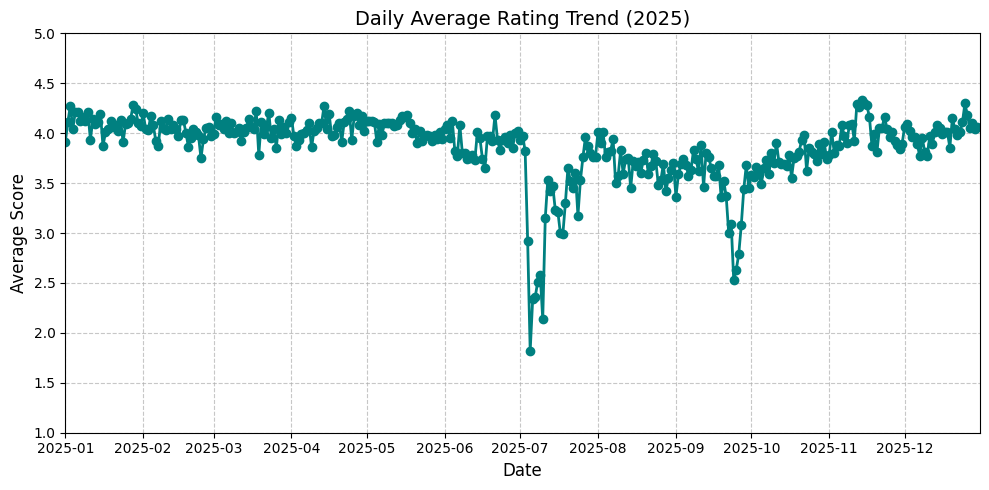

In [ ]:

# Group by date from the 'at' column and calculate the mean score
daily_mean_score = df_reviews_2025.groupby(df_reviews_2025['at'].dt.date)['score'].mean()

# Visualization Setup
plt.figure(figsize=(10, 5))
daily_mean_score.plot(kind='line', marker='o', color='teal', linewidth=2)
plt.xlim(pd.Timestamp('2025-01-01'), pd.Timestamp('2025-12-31'))


plt.title('Daily Average Rating Trend (2025)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.ylim(1, 5)
plt.tight_layout()
plt.show()

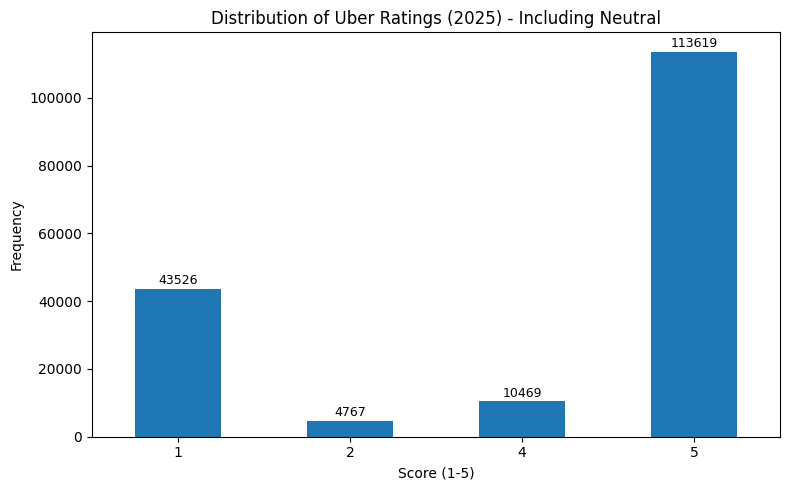

In [ ]:

# Visualize Score Distribution
df_reviews_2025['label'] = df_reviews_2025['score'].map({
    5: 2, # Positive
    4: 2, # Positive
    3: 1, # Neutral
    2: 0, # Negative
    1: 0  # Negative
})

# Drop rows only if the label is truly missing
df_reviews_2025 = df_reviews_2025.dropna(subset=['label'])
df_reviews_2025['label'] = df_reviews_2025['label'].astype(int)


plt.figure(figsize=(8,5))
counts = df_reviews_2025['score'].value_counts().sort_index()
counts.plot(kind='bar')
plt.title('Distribution of Uber Ratings (2025) - Including Neutral')
plt.xlabel('Score (1-5)')
plt.ylabel('Frequency')
plt.xticks(rotation=0)

# Adding data labels on top of each bar
for i, v in enumerate(score_counts):
    plt.text(i, v + 500, str(v), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

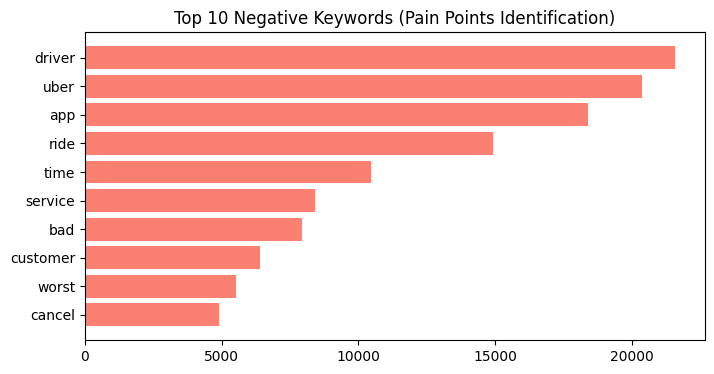

In [ ]:
# Key Insights: Top 10 Keywords in Negative Reviews
# Analyzing the most frequent complaints (pain points)
negative_reviews = df_reviews_2025[df_reviews_2025['label'] == 0]['clean_content']
all_neg_words = " ".join(negative_reviews).split()
most_common_neg = Counter(all_neg_words).most_common(10)

words, counts = zip(*most_common_neg)
plt.figure(figsize=(8, 4))
plt.barh(words, counts, color='salmon')
plt.title('Top 10 Negative Keywords (Pain Points Identification)')
plt.gca().invert_yaxis()
plt.show()

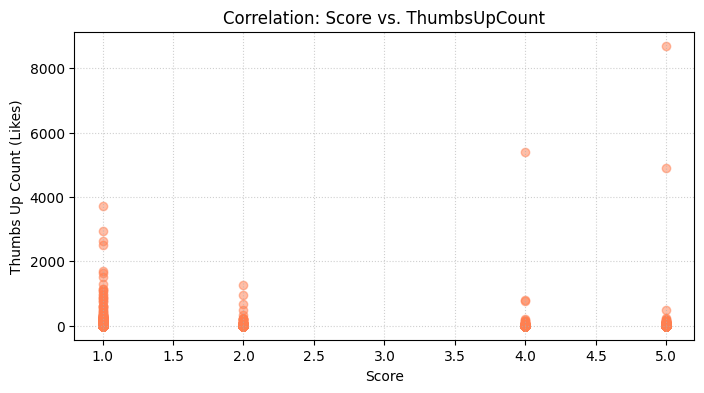

In [ ]:
# Correlation Analysis: Score vs. ThumbsUpCount
# Analyze if impactful complaints (high likes) are associated with lower scores
plt.figure(figsize=(8, 4))
plt.scatter(df_reviews_2025['score'], df_reviews_2025['thumbsUpCount'], alpha=0.5, color='coral')
plt.title('Correlation: Score vs. ThumbsUpCount')
plt.xlabel('Score')
plt.ylabel('Thumbs Up Count (Likes)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [ ]:
# Summary Statistics
print(df_reviews_2025[['score', 'thumbsUpCount']].describe())

               score  thumbsUpCount
count  172381.000000  172381.000000
mean        3.846311       0.714847
std         1.737417      33.901210
min         1.000000       0.000000
25%         1.000000       0.000000
50%         5.000000       0.000000
75%         5.000000       0.000000
max         5.000000    8701.000000
